In [39]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl
from scipy.spatial.distance import cdist 

In [40]:
# Sakurai medium concentrations
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

# Apply same transformation
sakurai_medium_log = np.log1p(sakurai_medium)

## Read data frames 

In [41]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols = [name for name in protocol_cols]

In [42]:
with open("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus/fitlered_populations.pkl", "rb") as file:
    filtered_df = pkl.load(file)["late_MgkPro"]

In [43]:
with open("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_old_measurements/fitlered_populations.pkl", "rb") as file:
    filtered_df_old_measurements = pkl.load(file)["late_MgkPro"]

## Concatenate

In [44]:
# Collect cell type specific values 
df = filtered_df
df_old_measurements = filtered_df_old_measurements

df["dataset"] = "New measurements"
df_old_measurements["dataset"] = "Original"
df_concatenated = pd.concat([df, df_old_measurements], axis=0)
df_concatenated["sakurai_dist"] = cdist(df_concatenated.loc[:, protocol_cols].values, sakurai_medium[None, :])

<Axes: xlabel='late_MgkPro_prop', ylabel='Density'>

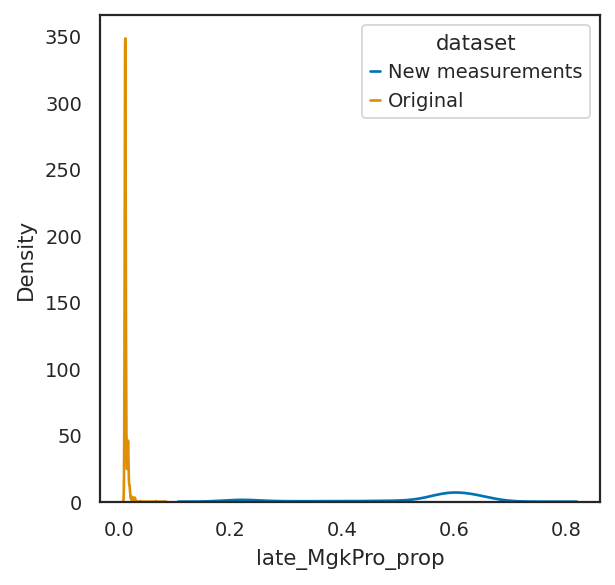

In [45]:
sns.set(style="white", context="paper")

sns.kdeplot(
    data=df_concatenated,
    x=f"late_MgkPro_prop",
    hue="dataset",
    common_norm=False,
    palette="colorblind"
)

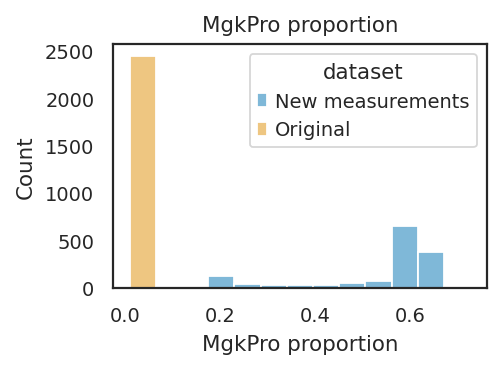

In [46]:
plt.figure(figsize=(3,2))
sns.histplot(df_concatenated, 
             x="late_MgkPro_prop", 
             hue="dataset",
             palette="colorblind")

plt.title("MgkPro proportion")
plt.xlabel("MgkPro proportion")
plt.show()

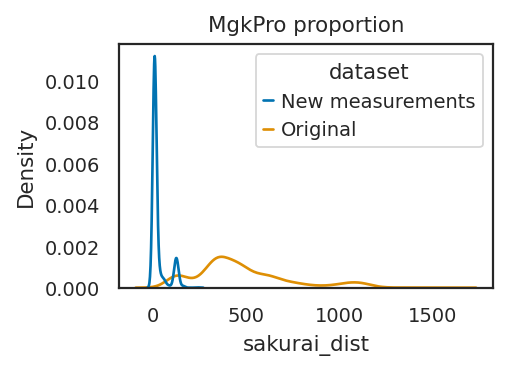

In [47]:
plt.figure(figsize=(3,2))

sns.kdeplot(df_concatenated, 
            x="sakurai_dist", 
            hue="dataset",
            palette="colorblind")
plt.title("MgkPro proportion")
plt.show()

# Uncertainty comparisons

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


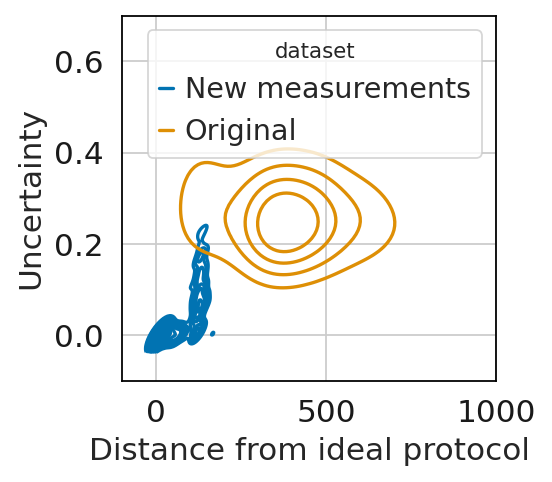

In [63]:
plt.figure(figsize=(3,3))
sns.kdeplot(
    data=df_concatenated,
    x="sakurai_dist",
    y="uncertainty_loss",
    hue="dataset",
    fill=False,
    linewidth=1.5,
    levels=30,
    palette="colorblind",
)

plt.xlabel("Distance from ideal protocol")
plt.ylabel("Uncertainty")

plt.xlim(-100, 1000)   # set your desired x-range
plt.ylim(-0.1, 0.7)    # set your desired y-range

plt.show()

Text(0.5, 1.0, 'MgkPro: Uncertainty distribution close solutions to Sakurai')

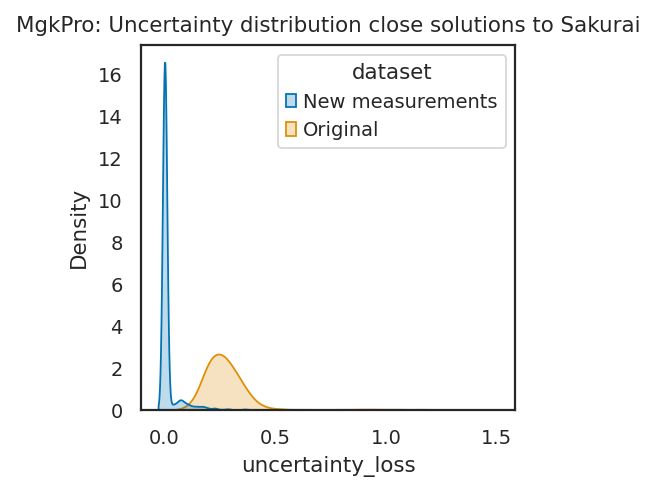

In [49]:
plt.figure(figsize=(3,3))
df_low = df_concatenated.query("sakurai_dist <500")

sns.kdeplot(
    data=df_low,
    x="uncertainty_loss",
    hue="dataset",
    palette="colorblind",
    fill=True
)

plt.title("MgkPro: Uncertainty distribution close solutions to Sakurai")

## Read unique concentrations and evaluate how uncertainty changed 

In [50]:
sc.settings.set_figure_params(figsize=(4, 4))

/tmp/ipykernel_4168751/3534239246.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(4, 4))


In [51]:
sakurai_medium_log.shape

(12,)

In [52]:
# Read unique solutions 
unique_solutions = sc.read_h5ad(
    "../../../../../../project_folder/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad"
)[:, 3:]

# Create AnnData object for Sakurai
sakurai = sc.AnnData(
    X=sakurai_medium_log[None, :],
    var=unique_solutions.var.copy()
)

sakurai.obs["is_sakurai"] = True

# Mark existing data
unique_solutions.obs["is_sakurai"] = False

# Concatenate datasets
unique_solutions_sakurai = sc.concat(
    [unique_solutions, sakurai],
    axis=0
)

# Recompute PCA
sc.tl.pca(unique_solutions_sakurai)

/tmp/ipykernel_4168751/2646550933.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  unique_solutions.obs["is_sakurai"] = False
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


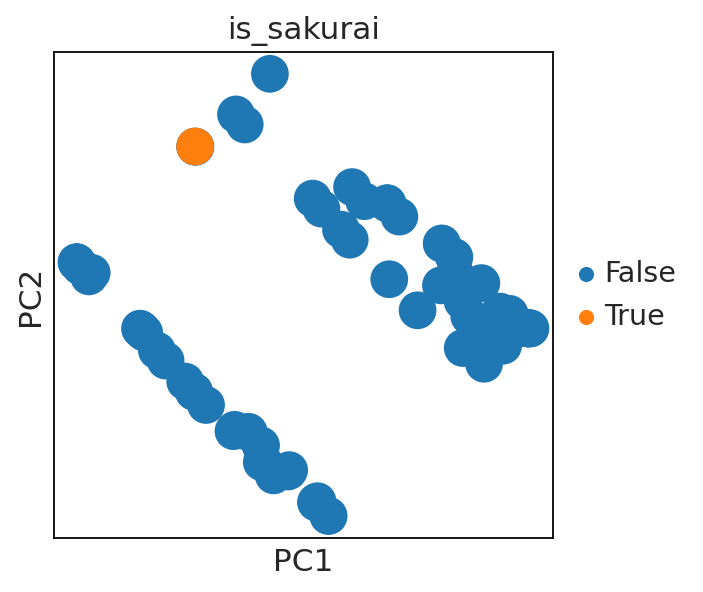

In [53]:
sc.pl.pca(unique_solutions_sakurai, color="is_sakurai")

## Project generated solutions onto PCs and visualize PCA plot 

In [54]:
mgkpro_original_new_measurements = filtered_df
mgkpro_original = filtered_df_old_measurements

mgkpro_original_vals = np.log1p(mgkpro_original.loc[:, protocol_cols].values)
mgkpro_original_new_measurements_vals = np.log1p(mgkpro_original_new_measurements.loc[:, protocol_cols].values)

In [55]:
np.max(mgkpro_original_vals, axis=0)

array([2.76469282, 1.55522191, 6.99975343, 7.40518808, 1.07272447,
       4.32056285, 4.99193241, 1.52669214, 0.95791033, 2.22730374,
       3.25273036, 3.04430051])

In [56]:
np.max(mgkpro_original_new_measurements_vals, axis=0)

array([2.47941686, 1.21341465, 5.3764782 , 5.3108978 , 0.45712556,
       4.29931966, 4.90051785, 1.07578052, 0.23879165, 2.62458779,
       3.19749835, 3.00325679])

In [57]:
generated_solutions = sc.AnnData(X=np.concatenate([mgkpro_original_vals, 
                                                   mgkpro_original_new_measurements_vals], axis=0), 
                                 obs={"dataset": ["original" for _ in range(len(mgkpro_original_vals))] + \
                                      ["new measurements" for _ in range(len(mgkpro_original_new_measurements_vals))]})

In [58]:
generated_solutions.obsm["X_pca"] = (generated_solutions.X - \
                                     unique_solutions_sakurai.X.mean(0)[None, :]).dot(unique_solutions_sakurai.varm["PCs"])

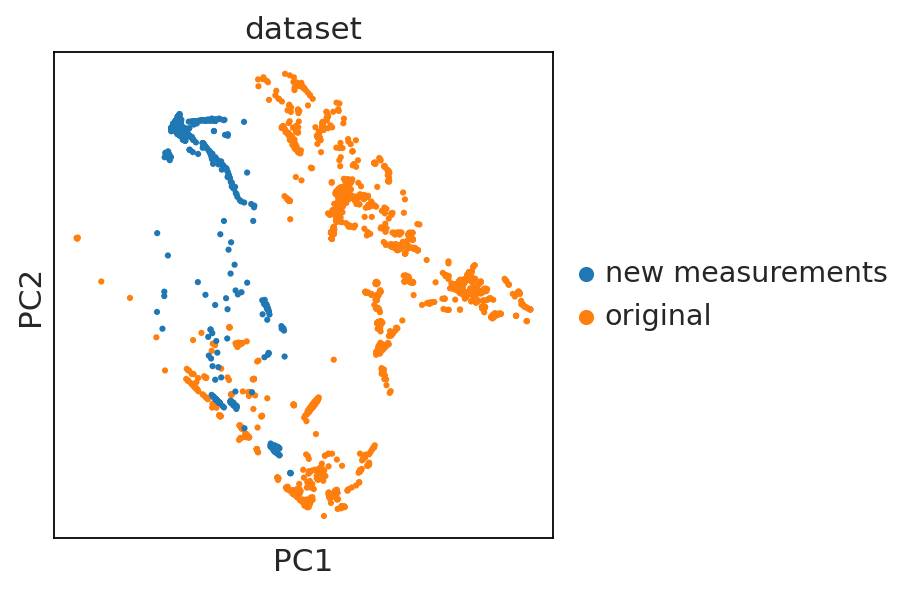

In [59]:
sc.pl.pca(generated_solutions, color="dataset")

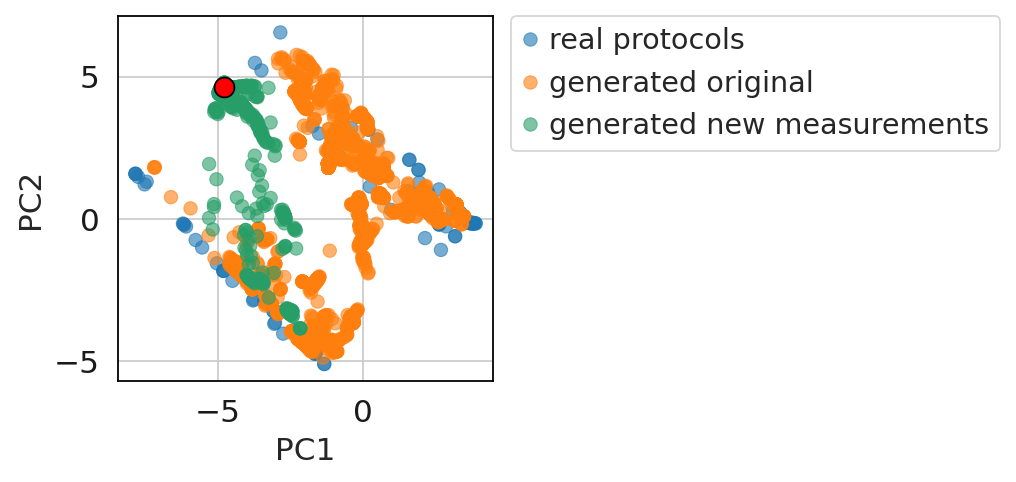

In [60]:
PC1 = np.concatenate([unique_solutions_sakurai.obsm["X_pca"][:, 0], 
                      generated_solutions.obsm["X_pca"][:,0]])
PC2 = np.concatenate([unique_solutions_sakurai.obsm["X_pca"][:, 1], 
                      generated_solutions.obsm["X_pca"][:,1]])
annotation = ["real protocols" for _ in range(len(unique_solutions_sakurai))] + \
["generated original" for _ in range(len(mgkpro_original_vals))] + \
["generated new measurements" for _ in range(len(mgkpro_original_new_measurements_vals))]

is_sakurai = unique_solutions_sakurai.obs["is_sakurai"].to_list() + [False for _ in range(len(generated_solutions))]

pcs_to_plot = pd.DataFrame({"PC1": PC1, 
                           "PC2": PC2, 
                           "Dataset": annotation, 
                           "is_Sakurai": is_sakurai})

plt.figure(figsize=(3,3))

# Plot all non-Sakurai points first
sns.scatterplot(
    data=pcs_to_plot[pcs_to_plot["is_Sakurai"] == False],
    x="PC1",
    y="PC2",
    hue="Dataset",
    edgecolor=None,
    alpha=0.6
)

# Overlay Sakurai points on top
sns.scatterplot(
    data=pcs_to_plot[pcs_to_plot["is_Sakurai"] == True],
    x="PC1",
    y="PC2",
    color="red",        # standout color
    s=80,               # bigger size
    edgecolor="black",  # outline helps visibility
    linewidth=0.8,
    zorder=10,          # ensure it's on top
    legend=False        # avoid duplicate legend
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()

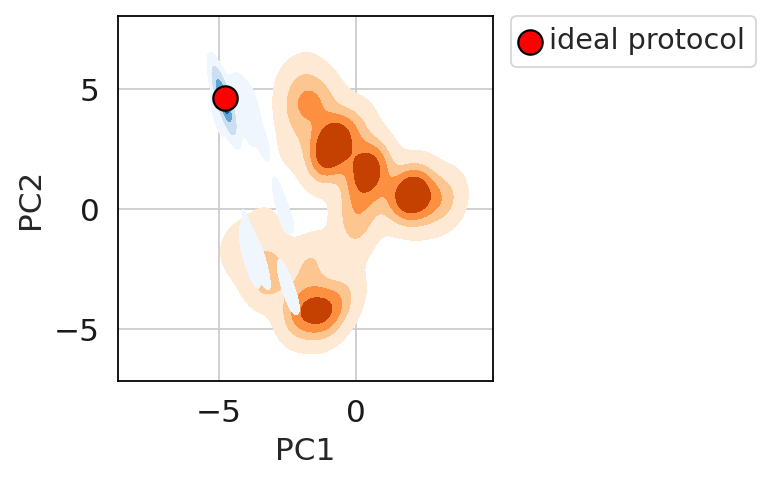

In [65]:
plt.figure(figsize=(3,3))

# --- OLD generated ---
sns.kdeplot(
    data=pcs_to_plot[
        (pcs_to_plot["Dataset"] == "generated original") &
        (pcs_to_plot["is_Sakurai"] == False)
    ],
    x="PC1",
    y="PC2",
    fill=True,
    alpha=1,
    levels=5,
    cmap="Oranges"
)

# --- NEW generated measurements ---
sns.kdeplot(
    data=pcs_to_plot[
        (pcs_to_plot["Dataset"] == "generated new measurements") &
        (pcs_to_plot["is_Sakurai"] == False)
    ],
    x="PC1",
    y="PC2",
    fill=True,
    alpha=1,
    levels=5,
    cmap="Blues"
)

# # --- optional: real protocols density ---
# sns.kdeplot(
#     data=pcs_to_plot[
#         (pcs_to_plot["Dataset"] == "real protocols") &
#         (pcs_to_plot["is_Sakurai"] == False)
#     ],
#     x="PC1",
#     y="PC2",
#     fill=False,
#     levels=10,
#     color="gray",
#     linewidths=1
# )

# --- Sakurai point ON TOP ---
sns.scatterplot(
    data=pcs_to_plot[pcs_to_plot["is_Sakurai"] == True],
    x="PC1",
    y="PC2",
    color="red",
    s=120,
    edgecolor="black",
    linewidth=1,
    zorder=20,
    label="ideal protocol"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

plt.show()